# 04 — Event Study EDA

Explores `src/features/event_study.py`'s output (cumulative abnormal
returns around dividend ex-dates) and runs the significance testing
from `src/models/event_study_stats.py` on top of it.

Run `python -m src.features.event_study` first if
`event_study_dividends.parquet` doesn't exist yet.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from src.models.event_study_stats import test_car_significance, test_car_by_sign

PROCESSED = Path("../data/processed")
study = pd.read_parquet(PROCESSED / "event_study_dividends.parquet")
print(study.shape)
study.head()

(1027, 5)


,ticker,ex_date,dividend_rate,car,n_valid_days
0,LITE,2020-12-21,1.00,-0.043964,5
1,CARG,2020-12-15,1.90,0.000582,5
2,CTHR,2020-12-16,1.45,0.018376,4
3,CARS,2020-12-21,0.75,0.038189,5
4,RIL,2020-12-22,0.10,-0.055368,5


## Distribution of CAR around dividend ex-dates

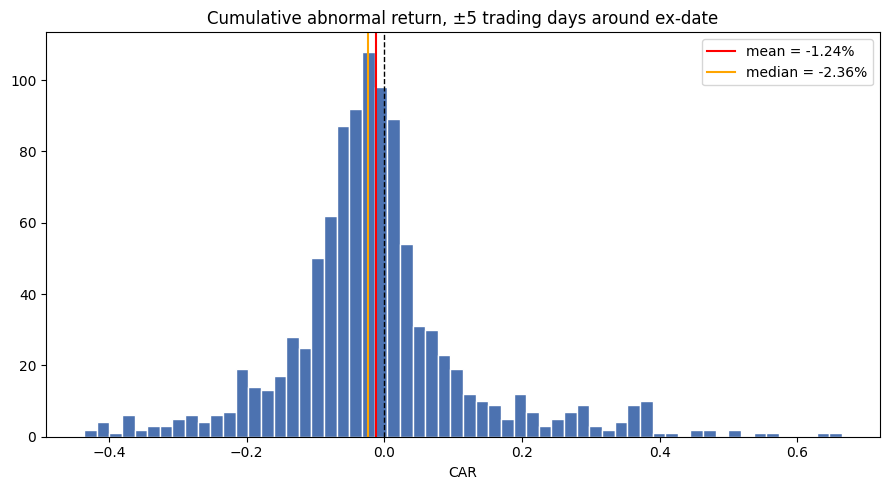

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(study["car"], bins=60, color="#4c72b0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(study["car"].mean(), color="red", linewidth=1.5, label=f"mean = {study['car'].mean():.2%}")
ax.axvline(study["car"].median(), color="orange", linewidth=1.5, label=f"median = {study['car'].median():.2%}")
ax.set_title("Cumulative abnormal return, ±5 trading days around ex-date")
ax.set_xlabel("CAR")
ax.legend()
plt.tight_layout()
plt.show()

The distribution is roughly centered near zero with a longer left tail
-- consistent with the mean CAR being slightly negative (see the
significance test below). This is a market-adjusted CAR (beta assumed
= 1, not estimated per-stock), so part of this negative drift is
plausibly the mechanical ex-dividend price drop itself rather than a
bearish market reaction -- the README flags this explicitly as a
limitation of the simplified single-factor model, not something this
notebook resolves.

## Is the mean CAR statistically different from zero?

In [3]:
result = test_car_significance(study["car"])
print(f"n events        = {result.n_events}")
print(f"mean CAR        = {result.mean_car:.4%}")
print(f"std CAR         = {result.std_car:.4%}")
print(f"t-statistic     = {result.t_stat:.3f}")
print(f"p-value         = {result.p_value:.4f}")
print(f"significant 5%  = {result.significant_at_5pct}")

n events        = 1027
mean CAR        = -1.2373%
std CAR         = 13.8385%
t-statistic     = -2.865
p-value         = 0.0043
significant 5%  = True


With p well under 0.05, the mean CAR is statistically distinguishable
from zero -- but statistically significant is not the same as
economically large; a ~1% average CAR over an 11-day window is a modest
effect, and (as above) partly mechanical rather than purely
informational.

## Does CAR differ by dividend size?

In [4]:
by_size = test_car_by_sign(study)
by_size[["group", "n_events", "mean_car", "t_stat", "p_value", "significant_at_5pct"]]

,group,n_events,mean_car,t_stat,p_value,significant_at_5pct
0,below_median_dividend,477,-0.005670,-0.924718,0.355581,False
1,above_median_dividend,550,-0.018187,-3.003262,0.002793,True


Larger (above-median) dividend payouts show a more negative and more
statistically significant mean CAR than smaller ones. This is
consistent with the ex-dividend mechanical drop being roughly
proportional to the dividend rate -- a bigger payout mechanically knocks
more off the price on the ex-date, inflating the size of the negative
CAR for that group, again pointing back at the beta=1 simplification
rather than necessarily meaning "the market punishes big dividends"
as an economic story.

## Sanity check: no extreme outliers remain

In [5]:
extreme = study[study["car"].abs() > 1.0]
print(f"Events with |CAR| > 100%: {len(extreme)}")
print(f"Max |CAR| in the dataset: {study['car'].abs().max():.2%}")

Events with |CAR| > 100%: 0
Max |CAR| in the dataset: 66.49%


This matches the README's data-quality note: a single event originally
produced a 98,500% CAR, traced to an implausible single-day price move
in the raw source file. The >50% daily-return filter in
`event_study.py` catches that class of error, and this check (also
codified in `tests/test_pipeline.py::TestEventStudy`) confirms no
similar outlier has crept back in.